# Stellar Coordinate Explorer - Basic Visualization (Biased)

## Objective
Create a simple scatter plot of Right Ascension vs Declination for the 10,000 sources in the randomly selected catalog.

## Why this matters
<!-- - Before any observation run, radio astronomers often plot source positions to check sky coverage and identify potential calibrators. -->
- A simple RA-Dec plot reveals large-scale patterns (e.g., the Milky Way plane, avoidance of the Galactic plane in some surveys).
- This is also the foundation for more advanced projections like Aitoff or Mollweide.
- Visualizing the random sample allows us to compare its spatial distribution with the previous biased sample.

## Dataset
- Input: `sources_with_galactic_random.fits`
- Columns used: `ra`, `dec`, `phot_g_mean_mag`

## Goals for Today
- Load the random table 10,000-source table with Galactic coordinates (but use RA/Dec)
- Generate a standard `matplotlib` scatter plot of `dec` vs `ra`
- Label axes correctly (RA in degress, Dec in degrees)
- Observe and note any patterns (e.g., gaps, clusters, the Galactic plane)
- Compare side-by-side with the biased sample from `05_viz_biased.ipynb`

## Checkpoint
- Table loaded successfully
- Scatter plot generated (`dec` on y, `ra` on x)
- Axes have labels and title includes N = 10000
- Observations based on the plots noted 

## Code
### 1. Setup and Loading

In [1]:
# Imports
import matplotlib.pyplot as plt
from astropy.table import Table

# Load the random sample and biased sample sources in seperate tables
table_random = Table.read("../../data/sources_with_galactic_coord_random.fits")
table_biased = Table.read("../../data/sources_with_galactic_coord_biased.fits")

Let's check for missing data in the `ra` and `dec` columns for the random data:

In [2]:
table_random.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12


The columns `ra` and `dec` appear to have no missing values (`n_bad` is 0 for both columns). We can now prepare them for plotting.

### 2. Simple Scatter Plot

In [ ]:
# Obtain the ra and dec values for the random sample
ra_random, dec_random = table_random['ra'], table_random['dec']

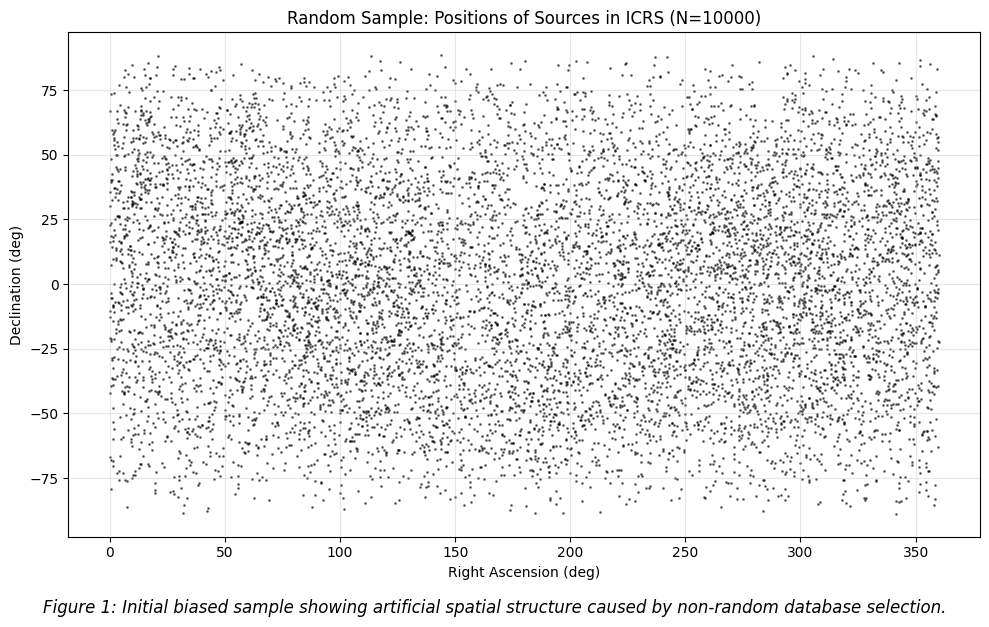

In [14]:
import textwrap

# RA vs Dec scatter plot for random sample

plt.figure(figsize=(10, 6))
plt.scatter(ra_random, dec_random, s=1, alpha=0.5, color='black')
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title(f"Random Sample: Positions of Sources in ICRS (N={len(table_random)})") 
plt.grid(True, alpha=0.3)

# Caption
fig_caption = 'Figure 1: Initial biased sample showing artificial spatial structure caused by non-random database selection.'
wrapper = textwrap.TextWrapper(width=110)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)

plt.tight_layout()
plt.figtext(0.5, -0.03, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/random_sample_ra_dec_space.png', dpi=300, bbox_inches='tight')
plt.show()

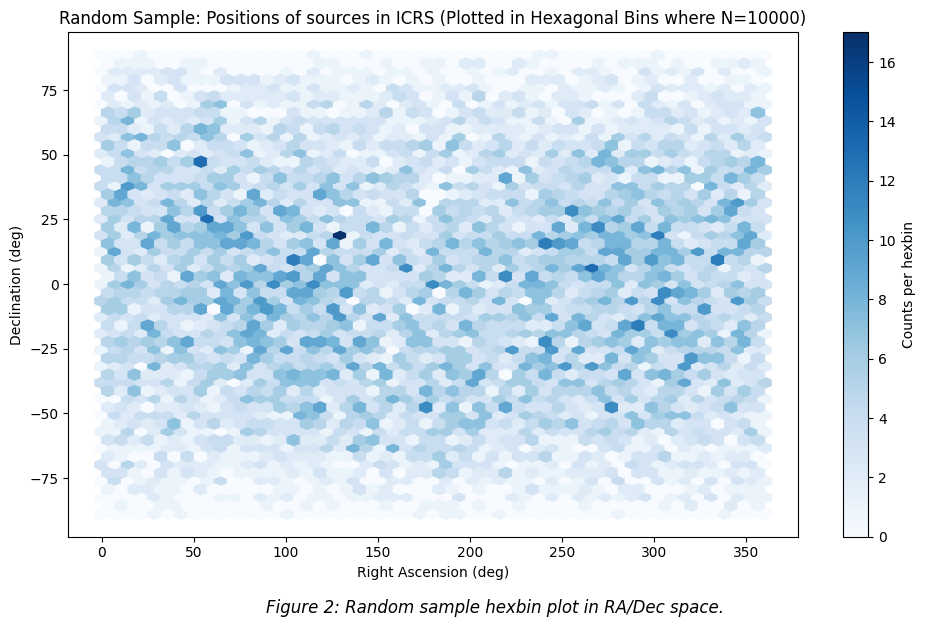

In [13]:
# RA vs Dec Hexbin plot for random sample

plt.figure(figsize=(10, 6))
plt.hexbin(ra_random, dec_random, gridsize=50, cmap='Blues') 
plt.colorbar(label='Counts per hexbin')
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title(f"Random Sample: Positions of sources in ICRS (Plotted in Hexagonal Bins where N={len(table_random)})") 

# Caption
fig_caption = 'Figure 2: Random sample hexbin plot in RA/Dec space.'
wrapper = textwrap.TextWrapper(width=150)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)


plt.tight_layout()
plt.figtext(0.5, -0.03, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/random_sample_hexbin_ra_dec_space.png', dpi=300, bbox_inches='tight')
plt.show()

We can also compare the biased sample with the random sample:

In [11]:
# Obtain the ra and dec values for the biased sample
ra_biased, dec_biased = table_biased['ra'], table_biased['dec']

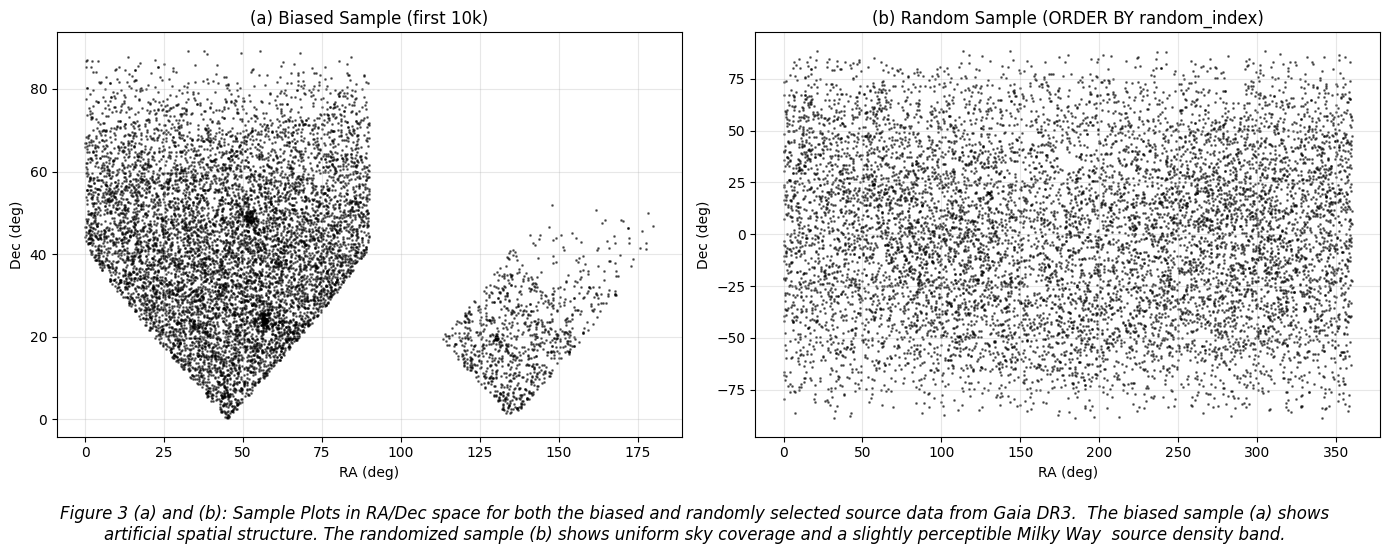

In [12]:
# RA vs Dec scatter plot for both random and biased sample

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


# Biased sample
ax1.scatter(ra_biased, dec_biased, s=1, alpha=0.5, color='black')
ax1.set_title('(a) Biased Sample (first 10k)')
ax1.set_xlabel('RA (deg)')
ax1.set_ylabel('Dec (deg)')
ax1.grid(True, alpha=0.3)


# Random sample
ax2.scatter(ra_random, dec_random, s=1, alpha=0.5, color='black')
ax2.set_title('(b) Random Sample (ORDER BY random_index)')
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Dec (deg)')
ax2.grid(True, alpha=0.3)


# Caption
fig_caption = """Figure 3 (a) and (b): Sample Plots in RA/Dec space for both the biased and randomly selected source data from Gaia DR3. 
The biased sample (a) shows artificial spatial structure. The randomized sample (b) shows uniform sky coverage and a slightly perceptible Milky Way 
source density band."""
wrapper = textwrap.TextWrapper(width=150)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)



plt.tight_layout()
plt.figtext(0.5, -0.09, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.savefig('../../outputs/biased_and_random_samples.png', dpi=300, bbox_inches='tight')
plt.show()


## Observations
- The random sample appears more evenly distributed across the sky compared to the biased sample which shows two approximately geometric regions containing sources with boundaries. 
- The biased sample shows significant increase in density beginning Dec $90^\degree$ moving towards Dec $0^\degree$ and within what appears as two approximately geometrical regions with boundaries beginning around RA $\approx 0^\degree$ to $\approx 87^\degree$ and $\approx 112^\degree$ to $\approx 175^\degree$. 
- The random sample has a more homogeneous distribution in comparison with the biased sample. 
- The random sample exhibits a slightly denser horizontal band in the middle and sparser distribution at the top and bottom furthest from the Dec $0^\degree$. 